# League of Legends Match Predictor


### Setup


### Step 1: Data Loading and Preprocessing


In [ ]:
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv"

data = pd.read_csv(url)

data.head()

X = data.drop("win", axis=1)
y = data["win"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

### Step 2: Logistic Regression Model


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
# Define Logistic Regression Model
class logistic_regression(nn.Module):
    def __init__(self, input_dim):
        super(logistic_regression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        output = self.linear(x)
        return torch.sigmoid(output)
# Number of input features
input_dim = X_train.shape[1]

# Initialize model
model = logistic_regression(input_dim)

# Loss function
criterion = nn.BCELoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

### Step 3: Hyperparameter Tuning


In [ ]:

learning_rates = [0.01, 0.05, 0.1]

results = {}

for lr in learning_rates:
    # Reinitialize model
    # model_tuned = logistic_regression(input_dim)
    model_tuned = model

    # New optimizer for this learning rate
    optimizer = optim.SGD(model_tuned.parameters(), lr=lr)

    # Train model
    num_epochs = 200

    for epoch in range(num_epochs):
        model_tuned.train()

        optimizer.zero_grad()

        outputs = model_tuned(X_train)

        loss = criterion(outputs, y_train.view(-1, 1))

        loss.backward()

        optimizer.step()

    # Evaluate on test set
    model_tuned.eval()

    with torch.no_grad():
        test_outputs = model_tuned(X_test)

        test_predictions = (test_outputs >= 0.5).float()

        test_accuracy = (
            test_predictions.eq(y_test.view(-1, 1)).sum().item()
            / y_test.shape[0]
        )

    results[lr] = test_accuracy

    print(
        f"Learning Rate: {lr}, "
        f"Test Accuracy: {test_accuracy * 100:.2f}%"
    )

### Step 4: Model Training


In [ ]:
#Number of epochs
# how to Add learning rate to the model tuned

learning_rate = 0.01

optimizer = torch.optim.SGD(
    model_tuned.parameters(),
    lr=learning_rate
)
epochs = 200
for epoch in range(epochs):
    # Training phase
    model.train()
    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)

    # Make sure y_train has the same shape as outputs
    loss = criterion(outputs, y_train.view(-1, 1))

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

#Model evaluation

model.eval()
with torch.no_grad():
    #Prediction
    train_outputs = model(X_train)
    test_outputs = model(X_test)

    # Convert probabilities to class labels using threshold 0.5
    train_predictions = (train_outputs >= 0.5).float()
    test_predictions = (test_outputs >= 0.5).float()

    # Calculate accuracy
    train_accuracy = (
        train_predictions.eq(y_train.view(-1, 1)).sum().item()
        / y_train.shape[0]
    )

    test_accuracy = (
        test_predictions.eq(y_test.view(-1, 1)).sum().item()
        / y_test.shape[0]
    )

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch [100/1000], Loss: 0.6852
Epoch [200/1000], Loss: 0.6852
Epoch [300/1000], Loss: 0.6852
Epoch [400/1000], Loss: 0.6852
Epoch [500/1000], Loss: 0.6852
Epoch [600/1000], Loss: 0.6852
Epoch [700/1000], Loss: 0.6852
Epoch [800/1000], Loss: 0.6852
Epoch [900/1000], Loss: 0.6852
Epoch [1000/1000], Loss: 0.6852
Training Accuracy: 54.37%
Test Accuracy: 50.50%

### Step 4: Model Optimization and Evaluation


In [ ]:
# model_l2 = logistic_regression(input_dim)

# # Loss function
# criterion = nn.BCELoss()
# # Optimizer with L2 regularization
# optimizer_l2 = optim.SGD(
#     model_l2.parameters(),
#     lr=0.01,
#     weight_decay=0.01
# )
# # Train for 1000 epochs
# num_epochs = 1000

# for epoch in range(num_epochs):
#     model_l2.train()

#     optimizer_l2.zero_grad()

#     outputs = model_l2(X_train)

#     loss = criterion(outputs, y_train.view(-1, 1))

#     loss.backward()

#     optimizer_l2.step()

#     if (epoch + 1) % 100 == 0:
#         print(
#             f"Epoch [{epoch + 1}/{num_epochs}], "
#             f"Loss: {loss.item():.4f}"
#         )

# model_l2.eval()

# with torch.no_grad():
#     train_outputs = model_l2(X_train)
#     test_outputs = model_l2(X_test)

#     train_predictions = (train_outputs >= 0.5).float()
#     test_predictions = (test_outputs >= 0.5).float()

#     train_accuracy_l2 = (
#         train_predictions.eq(y_train.view(-1, 1)).sum().item()
#         / y_train.shape[0]
#     )

#     test_accuracy_l2 = (
#         test_predictions.eq(y_test.view(-1, 1)).sum().item()
#         / y_test.shape[0]
#     )

# print(f"L2 Training Accuracy: {train_accuracy_l2 * 100:.2f}%")
# print(f"L2 Test Accuracy: {test_accuracy_l2 * 100:.2f}%")

Epoch [100/1000], Loss: 0.7244
Epoch [200/1000], Loss: 0.7100
Epoch [300/1000], Loss: 0.7007
Epoch [400/1000], Loss: 0.6948
Epoch [500/1000], Loss: 0.6911
Epoch [600/1000], Loss: 0.6888
Epoch [700/1000], Loss: 0.6874
Epoch [800/1000], Loss: 0.6866
Epoch [900/1000], Loss: 0.6860
Epoch [1000/1000], Loss: 0.6857
L2 Training Accuracy: 54.50%
L2 Test Accuracy: 48.00%

### Step 5: Visualization and Interpretation


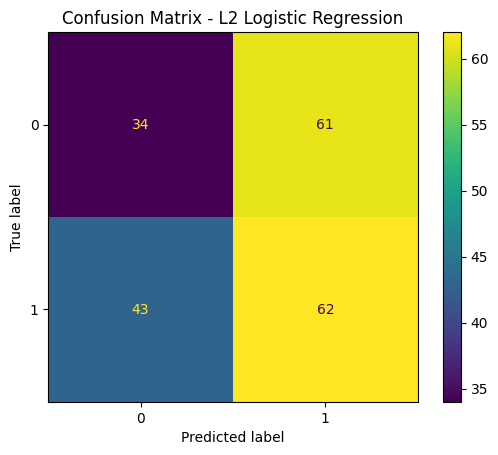

              precision    recall  f1-score   support

         0.0       0.44      0.36      0.40        95
         1.0       0.50      0.59      0.54       105

    accuracy                           0.48       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.48      0.47       200


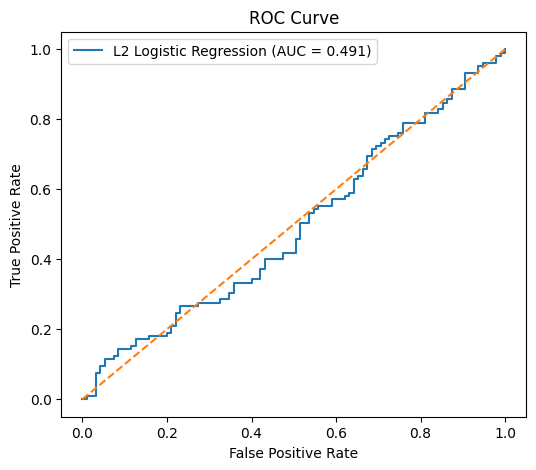

AUC Score: 0.4913

In [ ]:

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report
)

# Evaluate L2 model
# model_l2.eval()
model_tuned.eval()

with torch.no_grad():
    # Predicted probabilities
    y_prob_l2 = model_tuned(X_test).cpu().numpy().ravel()

# Convert probabilities to class predictions using threshold 0.5
y_pred_l2 = (y_prob_l2 >= 0.5).astype(int)

# True labels
y_true = y_test.cpu().numpy().ravel()

cm = confusion_matrix(y_true, y_pred_l2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - L2 Logistic Regression")
plt.show()

print(classification_report(y_true, y_pred_l2))

fpr, tpr, thresholds = roc_curve(y_true, y_prob_l2)

auc_score_l2 = roc_auc_score(y_true, y_prob_l2)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"L2 Logistic Regression (AUC = {auc_score_l2:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score_l2:.4f}")

### Step 6: Model Saving and Loading


In [ ]:
# Save the model
torch.save(model.state_dict(), 'logistic_regression_l2.pth')

# Load the model

# Create a new model instance
loaded_model = logistic_regression(input_dim)

# Load the saved parameters
loaded_model.load_state_dict(
    torch.load("logistic_regression_l2.pth")
)

# Set model to evaluation mode
loaded_model.eval()

# Ensure the loaded model is in evaluation mode
with torch.no_grad():
    test_outputs = loaded_model(X_test)

    test_predictions = (test_outputs >= 0.5).float()

    loaded_test_accuracy = (
        test_predictions.eq(y_test.view(-1, 1)).sum().item()
        / y_test.shape[0]
    )

print(f"Loaded Model Test Accuracy: {loaded_test_accuracy * 100:.2f}%")


# Evaluate the loaded model

print(f"Original L2 Test Accuracy: {test_accuracy_l2 * 100:.2f}%")
print(f"Loaded Model Test Accuracy: {loaded_test_accuracy * 100:.2f}%")



Loaded Model Test Accuracy: 50.50%
Original L2 Test Accuracy: 48.00%
Loaded Model Test Accuracy: 50.50%

Learning Rate: 0.01, Test Accuracy: 52.50%
Learning Rate: 0.05, Test Accuracy: 52.00%
Learning Rate: 0.1, Test Accuracy: 50.50%

### Step 8: Feature Importance


        Feature  Importance  Absolute Importance
3   gold_earned    0.175338             0.175338
0         kills    0.130939             0.130939
5  wards_placed    0.106084             0.106084
6  wards_killed   -0.034592             0.034592
7  damage_dealt   -0.018842             0.018842
2       assists   -0.013676             0.013676
4            cs   -0.007296             0.007296
1        deaths   -0.005118             0.005118

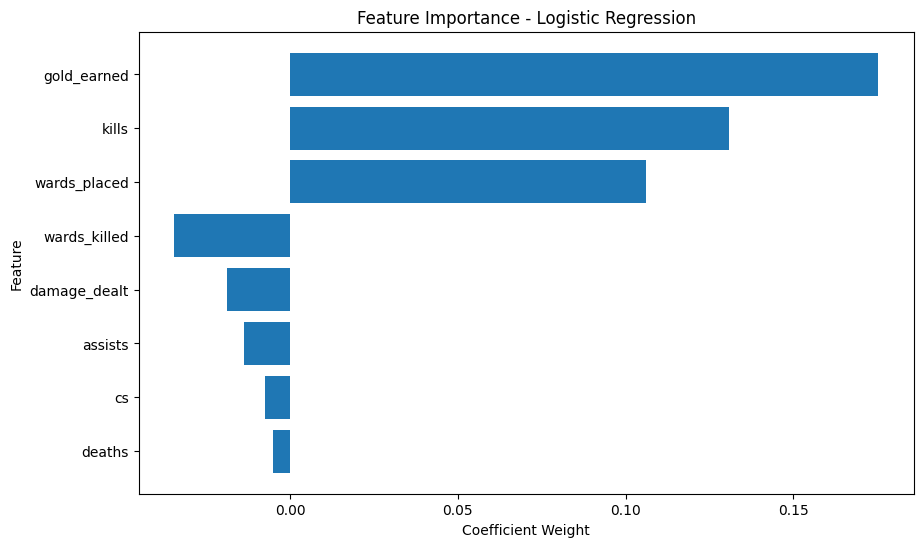

In [34]:

import pandas as pd
import matplotlib.pyplot as plt


# Extract learned weights from the linear layer
weights = model.linear.weight.detach().numpy().flatten()

# Get the original feature names
feature_names = X.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': weights
})

# Sort by absolute importance
importance_df['Absolute Importance'] = importance_df['Importance'].abs()

importance_df = importance_df.sort_values(
    by='Absolute Importance',
    ascending=False
)

# Display results
print(importance_df)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('Coefficient Weight')
plt.ylabel('Feature')
plt.title('Feature Importance - Logistic Regression')

plt.show()